# 48.1) KNN

In [4]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [6]:
pima_df=pd.read_csv('pima_indians_diabetes.csv')
pima_df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
x=pima_df.iloc[:,0:8]
y=pima_df.iloc[:,8]

In [10]:
x.head()

,preg,plas,pres,skin,test,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [12]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: class, dtype: int64

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,
    random_state=42)

In [18]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [22]:
model_ini=KNeighborsClassifier(n_neighbors=5)

In [24]:
model_ini.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


- Evaluate the model with train data

In [27]:
y_train_hat=model_ini.predict(x_train)

In [31]:
from sklearn.metrics import confusion_matrix,classification_report

In [33]:
cm_train=confusion_matrix(y_train,y_train_hat)
print(cm_train)

[[354  47]
 [ 77 136]]


In [37]:
clf_report_train=classification_report(y_train,y_train_hat)
print(clf_report_train)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       401
           1       0.74      0.64      0.69       213

    accuracy                           0.80       614
   macro avg       0.78      0.76      0.77       614
weighted avg       0.79      0.80      0.79       614



- Evaluate the model with test data

In [40]:
y_test_hat=model_ini.predict(x_test)

In [42]:
cm_test=confusion_matrix(y_test,y_test_hat)
print(cm_test)

[[70 29]
 [23 32]]


In [44]:
clf_report_test=classification_report(y_test,y_test_hat)
print(clf_report_test)

              precision    recall  f1-score   support

           0       0.75      0.71      0.73        99
           1       0.52      0.58      0.55        55

    accuracy                           0.66       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.66      0.67       154



- Hyperparameter tuning

In [53]:
train_acc=[]
test_acc=[]
for i in range(1,30):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    #y_hat_train=model.predict(x_train)
    #y_hat_test=model.predict(x_test)
    train_score=model.score(x_train,y_train)
    test_score=model.score(x_test,y_test)
    train_acc.append(train_score)
    test_acc.append(test_score)

In [55]:
train_acc

[1.0,
 0.8322475570032574,
 0.8550488599348535,
 0.8094462540716613,
 0.7980456026058632,
 0.7882736156351792,
 0.7931596091205212,
 0.7768729641693811,
 0.7931596091205212,
 0.7899022801302932,
 0.7866449511400652,
 0.7833876221498371,
 0.7899022801302932,
 0.7899022801302932,
 0.7850162866449512,
 0.7850162866449512,
 0.7833876221498371,
 0.7703583061889251,
 0.7752442996742671,
 0.7719869706840391,
 0.7736156351791531,
 0.7638436482084691,
 0.7654723127035831,
 0.762214983713355,
 0.760586319218241,
 0.747557003257329,
 0.757328990228013,
 0.755700325732899,
 0.749185667752443]

In [57]:
test_acc

[0.6753246753246753,
 0.7012987012987013,
 0.6493506493506493,
 0.7077922077922078,
 0.6623376623376623,
 0.7272727272727273,
 0.6883116883116883,
 0.7467532467532467,
 0.7207792207792207,
 0.7662337662337663,
 0.7337662337662337,
 0.7792207792207793,
 0.7727272727272727,
 0.7727272727272727,
 0.7597402597402597,
 0.7792207792207793,
 0.7727272727272727,
 0.7597402597402597,
 0.7532467532467533,
 0.7272727272727273,
 0.7402597402597403,
 0.7402597402597403,
 0.7142857142857143,
 0.7467532467532467,
 0.7142857142857143,
 0.7402597402597403,
 0.7272727272727273,
 0.7337662337662337,
 0.7142857142857143]

In [65]:
import matplotlib.pyplot as plt

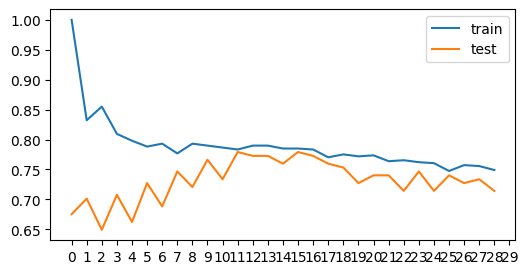

In [73]:

plt.figure(figsize=(6,3))
plt.plot(train_acc,label='train')
plt.plot(test_acc,label='test')
plt.xticks(range(0,30))
plt.legend()
plt.show()

- According to above graph we can say that accuracy is good at k=11. Lets build the model with k=11

In [112]:
best_model=KNeighborsClassifier(n_neighbors=11)

In [114]:
best_model.fit(x_train,y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


- evaluate best model train data

In [117]:
y_hat_train_11=best_model.predict(x_train)

In [119]:
cm_train_11=confusion_matrix(y_train,y_hat_train_11)
print(cm_train_11)

[[352  49]
 [ 82 131]]


In [121]:
clf_train_11=classification_report(y_train,y_hat_train_11)
print(clf_train_11)

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       401
           1       0.73      0.62      0.67       213

    accuracy                           0.79       614
   macro avg       0.77      0.75      0.75       614
weighted avg       0.78      0.79      0.78       614



In [123]:
- evaluate best model test data

SyntaxError: invalid syntax (2298425096.py, line 1)

In [125]:
y_hat_test_11=best_model.predict(x_test)

In [127]:
cm_test_11=confusion_matrix(y_test,y_hat_test_11)
print(cm_test_11)

[[79 20]
 [21 34]]


In [129]:
clf_test_11=classification_report(y_test,y_hat_test_11)
print(clf_test_11)

              precision    recall  f1-score   support

           0       0.79      0.80      0.79        99
           1       0.63      0.62      0.62        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

